# 07 · Training on real STEW recordings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/07_stew_real_experiment.ipynb)

This notebook is a Colab-friendly walkthrough of
`examples/stew_real_experiment.py`: it loads real STEW EEG windows, keeps
subjects disjoint across train/validation/test, trains both the GAT
baseline and the full Kuramoto-attention Neural ODE, and plots the results.
It never substitutes synthetic data — if `dataset/` is missing or malformed
the loader raises rather than making something up.

**What STEW is.** STEW ("Simultaneous Task EEG Workload", Lim, Sourina &
Wang, 2018) recorded 48 participants on a 14-channel Emotiv EPOC headset at
128 Hz doing two sessions each: a resting/low-workload baseline (`lo`) and
the demanding SIMKAP multitasking test (`hi`). The binary label used
everywhere below comes only from that `hi`/`lo` filename suffix.
`ratings.txt`, also bundled in this repository, holds each participant's own
1-9 subjective workload rating per session (`subject_id, rating_lo,
rating_hi`) — it is deliberately **not** used as a label or model input
here (see `data/stew.py`'s `condition_from_path`), only as optional
reference data for anyone who wants to correlate predictions with
self-reports.

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # Unlike the other example notebooks, this one needs the STEW recordings,
    # so it clones the full repository history -- including the ~490 MB
    # dataset/ folder bundled in this project (see the README's "STEW dataset
    # and ratings.txt" section). That can take a minute or two on Colab's
    # network. If you already have your own STEW copy (e.g. on Google Drive),
    # skip this cell and set DATA_ROOT to that path instead.
    subprocess.run(["git", "clone", "--quiet", "--depth", "1", REPO_URL, "repo"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2",
     "PyYAML>=6,<7", "matplotlib>=3.9,<4", "tqdm"],
    check=True,
)

DATA_ROOT = os.path.join(REPO_DIR, "dataset")
assert os.path.isdir(DATA_ROOT), f"expected STEW recordings under {DATA_ROOT}"

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository:   {REPO_DIR}")
print(f"STEW data root: {DATA_ROOT}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository:   /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
STEW data root: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE/dataset
torch 2.13.0 | CUDA available: False


## Alternative: bring your own STEW copy

If you'd rather not wait for the ~490 MB clone, mount Google Drive first and
point `DATA_ROOT` at your own copy before running the setup cell (STEW files
must be named like `sub01_hi.txt` / `sub01_lo.txt`, 14 numeric EEG columns
each):

```python
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_ROOT = '/content/drive/MyDrive/STEW'
```

## 1. A look at one recording

One raw channel, and the six interpretable rhythm features
(`RhythmPreprocessor.transform_window`: log power, relative power, Hilbert
amplitude, phase sine/cosine, spectral entropy) extracted for every band of
the first electrode in the first analysis window.

{'recordings': 96, 'subjects': 48, 'channels': ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'], 'sampling_frequency': 128.0}
sub01_hi.txt: subject 01, condition 'high', shape (14, 19200)


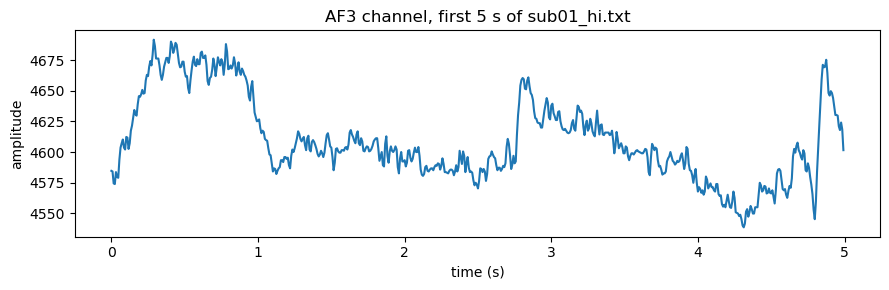

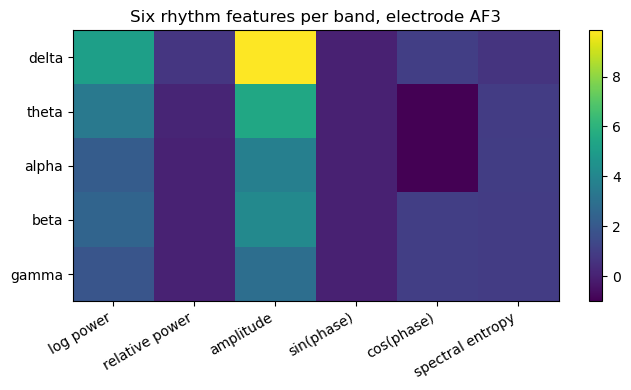

In [2]:
from hmb_kuramoto_ode.data.stew import STEWDataset
from hmb_kuramoto_ode.data.preprocessing import RhythmPreprocessor
from hmb_kuramoto_ode.contracts import DEFAULT_CHANNELS, BANDS

preprocessor = RhythmPreprocessor()
dataset = STEWDataset(DATA_ROOT, preprocessor)
print(dataset.inspect())

record = dataset.records[0]
raw = dataset.load(record)  # [14, samples]
print(f"{record.path.name}: subject {record.subject_id}, condition '{record.condition}', shape {raw.shape}")

fig, ax = plt.subplots(figsize=(9, 3))
seconds = np.arange(raw.shape[1]) / preprocessor.sfreq
five_seconds = int(preprocessor.sfreq * 5)
ax.plot(seconds[:five_seconds], raw[0, :five_seconds])
ax.set(xlabel="time (s)", ylabel="amplitude", title=f"{DEFAULT_CHANNELS[0]} channel, first 5 s of {record.path.name}")
fig.tight_layout()
plt.show()

start, window = preprocessor.windows(raw)[0]
features = preprocessor.transform_window(window)  # [14, 5, 6]
feature_names = ["log power", "relative power", "amplitude", "sin(phase)", "cos(phase)", "spectral entropy"]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(features[0], aspect="auto", cmap="viridis")
ax.set_xticks(range(6)); ax.set_xticklabels(feature_names, rotation=30, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(BANDS)
ax.set_title(f"Six rhythm features per band, electrode {DEFAULT_CHANNELS[0]}")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()


## 2. Subject-disjoint windows and split

`examples.stew_real_experiment` provides the same window-loading and
subject-grouped split used by the CLI: the split groups by subject, so no
subject's windows appear in more than one of train/validation/test.

In [3]:
import random

import examples.stew_real_experiment as real_experiment

seed_everything(7)
rows = real_experiment.load_windows(DATA_ROOT, limit_per_record=4)
print(f"{len(rows)} windows from {len({r[2] for r in rows})} subjects")

(train_rows, val_rows, test_rows), subjects = real_experiment.split_rows(rows)

# Subsample the training windows: with the real 14-electrode STEW graph,
# EdgeAttention's per-destination-node normalization scales steeply with
# batch size, so a small batch keeps this interactive notebook fast on a
# Colab CPU. Drop this cap (or raise it) to train on every window, or switch
# to configs/stew_full.yaml for the full protocol.
MAX_TRAIN_ROWS = 24
if len(train_rows) > MAX_TRAIN_ROWS:
    train_rows = random.Random(7).sample(train_rows, MAX_TRAIN_ROWS)

print(f"train subjects ({len(subjects[0])}, {len(train_rows)} windows kept):", sorted(subjects[0]))
print(f"validation subject: {subjects[1]} ({len(val_rows)} windows)")
print(f"test subject:       {subjects[2]} ({len(test_rows)} windows)")


Loading data:   0%|          | 0/96 [00:00<?, ?record/s]

Loading data:   2%|▏         | 2/96 [00:00<00:04, 19.47record/s]

Loading data:   5%|▌         | 5/96 [00:00<00:04, 20.26record/s]

Loading data:   8%|▊         | 8/96 [00:00<00:04, 20.31record/s]

Loading data:  11%|█▏        | 11/96 [00:00<00:04, 20.46record/s]

...

Loading data:  93%|█████████▎| 89/96 [00:04<00:00, 20.82record/s]

Loading data:  96%|█████████▌| 92/96 [00:04<00:00, 20.89record/s]

Loading data:  99%|█████████▉| 95/96 [00:04<00:00, 20.85record/s]

Loading data: 100%|██████████| 96/96 [00:04<00:00, 20.70record/s]

384 windows from 48 subjects
train subjects (46, 24 windows kept): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46']
validation subject: {'47'} (8 windows)
test subject:       {'48'} (8 windows)


In [4]:
from hmb_kuramoto_ode.data.preprocessing import TrainNormalizer

normalizer = TrainNormalizer().fit(np.stack([r[0] for r in train_rows]), [r[2] for r in train_rows])


def tensors(rows):
    features = normalizer.transform(np.stack([r[0] for r in rows]))
    x = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor([r[1] for r in rows], dtype=torch.long)
    return x, y


xtr, ytr = tensors(train_rows)
xval, yval = tensors(val_rows)
xtest, ytest = tensors(test_rows)
regions = xtr.shape[1]
print(f"train {tuple(xtr.shape)}, validation {tuple(xval.shape)}, test {tuple(xtest.shape)}")


train (24, 14, 5, 6), validation (8, 14, 5, 6), test (8, 14, 5, 6)


## 3. Training GAT and the full model

Both models share the same training loop (mirroring `main()` in
`examples/stew_real_experiment.py`): full-batch gradient descent per epoch,
gradient clipping, and best-validation-accuracy checkpointing before the
final test evaluation. A small number of epochs and windows keeps this fast
enough for an interactive Colab session — for the actual subject-independent
protocol (grouped cross-validation, early stopping, mixed precision), use
`configs/stew_full.yaml` with `hmb_kuramoto_ode.cli cross-validate`, as
described in the README.

In [5]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph, batch_edges
from hmb_kuramoto_ode.models.full_model import HierarchicalKuramotoODE

base_edges, _ = build_hierarchical_graph(regions)


def run_experiment(model_name, epochs=15, lr=0.01):
    seed_everything(7)
    full = model_name == "full"
    train_edges = batch_edges(base_edges, regions * 5, xtr.shape[0])
    val_edges = batch_edges(base_edges, regions * 5, xval.shape[0])
    test_edges = batch_edges(base_edges, regions * 5, xtest.shape[0])

    model = (HierarchicalKuramotoODE(train_edges, hidden=16) if full
             else real_experiment.GATClassifier(train_edges))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def set_edges(edges):
        if full:
            model.field.edge_index = edges
        else:
            model.edge_index = edges

    history, best = [], None
    for epoch in range(epochs):
        model.train(); set_edges(train_edges); optimizer.zero_grad()
        logits = model(xtr)["graph_logits"] if full else model(xtr)
        loss = nn.functional.cross_entropy(logits, ytr)
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()

        set_edges(val_edges)
        val_metrics, _ = real_experiment.evaluate(model, xval, yval, full)
        history.append({"epoch": epoch + 1, "train_loss": loss.item(), "val_accuracy": val_metrics["accuracy"]})
        state = {k: v.detach().clone() for k, v in model.state_dict().items() if not k.endswith("edge_index")}
        if best is None or val_metrics["accuracy"] > best[0]:
            best = (val_metrics["accuracy"], state)

    model.load_state_dict(best[1], strict=False)
    set_edges(test_edges)
    test_metrics, test_probability = real_experiment.evaluate(model, xtest, ytest, full)
    return history, test_metrics, test_probability


results = {}
for name in ("gat", "full"):
    hist, test_metrics, probability = run_experiment(name, epochs=15)
    results[name] = {"history": hist, "test_metrics": test_metrics, "probability": probability}
    print(f"{name}: test accuracy={test_metrics['accuracy']:.3f} roc_auc={test_metrics['roc_auc']}")


gat: test accuracy=0.500 roc_auc=0.6875


full: test accuracy=0.625 roc_auc=0.5625


## 4. Results

Training curves, confusion matrices, and an ROC curve on the single held-out
test subject. With only a handful of windows per recording and a few
epochs, don't expect strong accuracy here — this notebook favors a fast,
honest, reproducible run over a flattering one; see the README's
reproducibility section and `reports/real_stew_status.md` for the caveats
that apply to any STEW accuracy number.

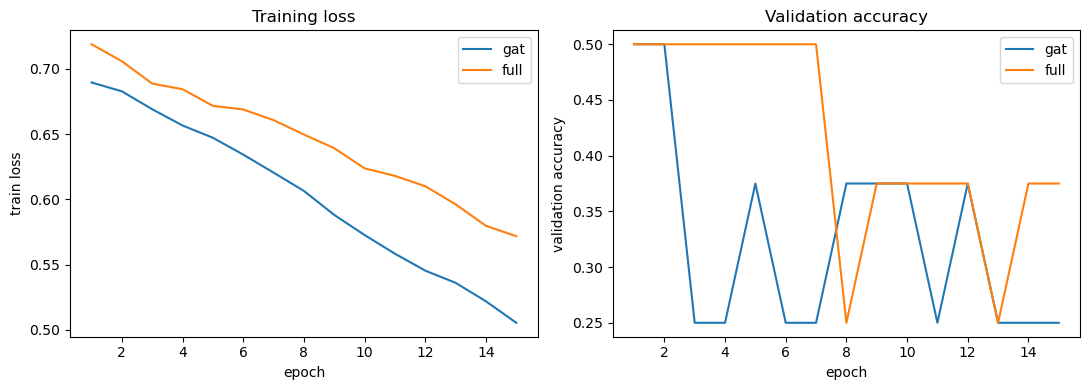

gat test confusion matrix (rows=true [lo,hi], cols=predicted):
[[0 4]
 [0 4]]
full test confusion matrix (rows=true [lo,hi], cols=predicted):
[[1 3]
 [0 4]]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, result in results.items():
    epochs = [h["epoch"] for h in result["history"]]
    axes[0].plot(epochs, [h["train_loss"] for h in result["history"]], label=name)
    axes[1].plot(epochs, [h["val_accuracy"] for h in result["history"]], label=name)
axes[0].set(xlabel="epoch", ylabel="train loss", title="Training loss")
axes[1].set(xlabel="epoch", ylabel="validation accuracy", title="Validation accuracy")
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

for name, result in results.items():
    cm = np.array(result["test_metrics"]["confusion_matrix"])
    print(f"{name} test confusion matrix (rows=true [lo,hi], cols=predicted):\n{cm}")


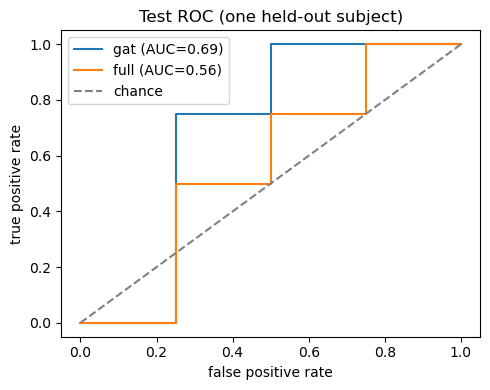

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
target = ytest.numpy()
for name, result in results.items():
    probability = np.array(result["probability"])
    if len(set(target.tolist())) == 2:
        fpr, tpr, _ = roc_curve(target, probability)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="chance")
ax.set(xlabel="false positive rate", ylabel="true positive rate", title="Test ROC (one held-out subject)")
ax.legend()
fig.tight_layout()
plt.show()


## Try it yourself

- Increase `--windows-per-record` / `epochs` in `run_experiment`, or switch
  to `configs/stew_full.yaml` + `hmb_kuramoto_ode.cli cross-validate` for the
  full grouped cross-validation protocol.
- Compare `HierarchicalKuramotoODE` ablation switches (`grand=False`,
  `kuramoto=False`, ...) on real data, the way notebook 06 does on synthetic
  data.
- Load `ratings.txt` (`REPO_DIR/ratings.txt`, columns `subject_id,
  rating_lo, rating_hi`) and check whether a subject's self-reported
  workload gap correlates with how confidently the model separates their
  `hi`/`lo` windows — remember it was never used for training or labels.